# 3) Learning Detection — Sequence Criterion (Strategy 1)

This notebook demonstrates the **Sequence Criterion** learning detection method (Figure 3, “Strategy 1” in the paper).



In [31]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)


[standardize_dataset] Removed 11 omission trial(s) from 'Choice'.


In [32]:
# Load test data

no_Trials = len(TestData)

# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "go_uncued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

rule_strategies = ["go_left", "go_right", "go_cued"]


strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")



TestData.head()

,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,Group,Overtrain,RT,RuleChangeTrials,NewSessionTrials,StartDate
0,1,1,go right,left,right,no,OT,no,0.4,0,0,06-Mar-2023
1,2,1,go right,left,left,no,OT,no,0.8,0,0,06-Mar-2023
2,3,1,go right,left,left,no,OT,no,0.6,0,0,06-Mar-2023
3,4,1,go right,right,right,yes,OT,no,0.4,0,0,06-Mar-2023
4,5,1,go right,left,right,no,OT,no,0.4,0,0,06-Mar-2023


In [33]:
# Initialise storage
alpha0, beta0 = set_priors(prior_type) 

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [34]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):
    
    rows_of_data = TestData.iloc[0:trial+1]
    
    for strategy in strategies:
        
        strategy_fcn = getattr(strategymodels, strategy)
        trial_type = strategy_fcn(rows_of_data)
        
        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )
        
        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total
        
        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")
        
        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }
        
        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]
        
        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )
        
        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_82948/3955232189.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


In [35]:
# Session-end lookup: for each trial, find the last trial index of its session
session_last = TestData.groupby("SessionIndex").apply(lambda g: g.index[-1], include_groups=False)
TestData["session_end_idx"] = TestData["SessionIndex"].map(session_last)
session_end_array = TestData["session_end_idx"].values

print("Session end indices:")
for sid in sorted(TestData["SessionIndex"].unique()):
    end_idx = int(TestData[TestData["SessionIndex"] == sid].index[-1])
    rule = TestData[TestData["SessionIndex"] == sid]["TargetRule"].iloc[0]
    print(f"  Session {sid}: ends at trial index {end_idx}  (rule: {rule})")

Session end indices:
  Session 1: ends at trial index 106  (rule: go right)
  Session 2: ends at trial index 203  (rule: go right)
  Session 3: ends at trial index 309  (rule: go right)
  Session 4: ends at trial index 407  (rule: go left)
  Session 5: ends at trial index 470  (rule: go left)
  Session 6: ends at trial index 570  (rule: go right)
  Session 7: ends at trial index 676  (rule: go right)
  Session 8: ends at trial index 776  (rule: go left)
  Session 9: ends at trial index 881  (rule: go left)
  Session 10: ends at trial index 981  (rule: go right)
  Session 11: ends at trial index 1033  (rule: go right)
  Session 12: ends at trial index 1132  (rule: go left)
  Session 13: ends at trial index 1207  (rule: go left)
  Session 14: ends at trial index 1307  (rule: go right)
  Session 15: ends at trial index 1348  (rule: go right)
  Session 16: ends at trial index 1448  (rule: go left)
  Session 17: ends at trial index 1489  (rule: go left)
  Session 18: ends at trial index 158

In [36]:
print(TestData.iloc[313][["TrialIndex", "SessionIndex", "TargetRule"]])
print(TestData.iloc[314][["TrialIndex", "SessionIndex", "TargetRule"]])

TrialIndex          319
SessionIndex          4
TargetRule      go left
Name: 313, dtype: object
TrialIndex          320
SessionIndex          4
TargetRule      go left
Name: 314, dtype: object


In [37]:
def detect_learning_per_block_targeted(Output_collection,
                                       block_starts,
                                       block_ends,
                                       block_target_strategies,
                                       session_end_array,
                                       chance_level=0.5,
                                       min_trials=5):
    """
    For each block, detect learning using the correct strategy for that block.
    Learning criterion: MAP stays above chance_level from trial t until the END OF THE SESSION
    (last trial of the same SessionIndex as trial t — not the block end).
    """
    learning_trials = []

    for start, end, target_strategy in zip(block_starts, block_ends, block_target_strategies):

        MAP = Output_collection[target_strategy]["MAPprobability"].values

        lt = None
        for t in range(start, end):
            sess_end = int(session_end_array[t]) + 1
            remaining = MAP[t:sess_end]
            if len(remaining) >= min_trials and np.all(remaining > chance_level):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

if "RuleChangeTrials" in TestData.columns:
    block_boundaries = list(TestData.index[TestData["RuleChangeTrials"] == 1])
else:
    block_boundaries = []

block_starts = [0] + block_boundaries
block_ends   = block_boundaries + [len(TestData)]

if "TargetRule" in TestData.columns:
    block_labels = [TestData.iloc[s]["TargetRule"] for s in block_starts]
else:
    block_labels = ["go right", "go to the lit arm", "go left", "go to the dark arm"][:len(block_starts)]



In [38]:
# -------------------------------------------------
# Map each task rule to the corresponding strategy
# -------------------------------------------------

rule_to_strategy = {
    "go right": "go_right",
    "Right Arm": "go_right",
    "go to the lit arm": "go_cued",
    "Lit Arm": "go_cued",
    "go left": "go_left",
    "Left Arm": "go_left",
    "go to the dark arm": "go_uncued",
    "Unlit Arm": "go_uncued"
}

block_target_strategies = [rule_to_strategy[label] for label in block_labels]
print("Block labels:", block_labels)
print("Strategy mapping:", block_target_strategies)

Block labels: ['go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right']
Strategy mapping: ['go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right']


In [39]:
chance_level = 0.5

learning_trials_blocks = detect_learning_per_block_targeted(
    Output_collection=Output_collection,
    block_starts=block_starts,
    block_ends=block_ends,
    block_target_strategies=block_target_strategies,
    session_end_array=session_end_array,
    chance_level=chance_level
)

print("Learning trials per block:", learning_trials_blocks)

Learning trials per block: [28, 300, 465, 620, 862, 1025, 1176, 1349, 1485, 1624, 1752]


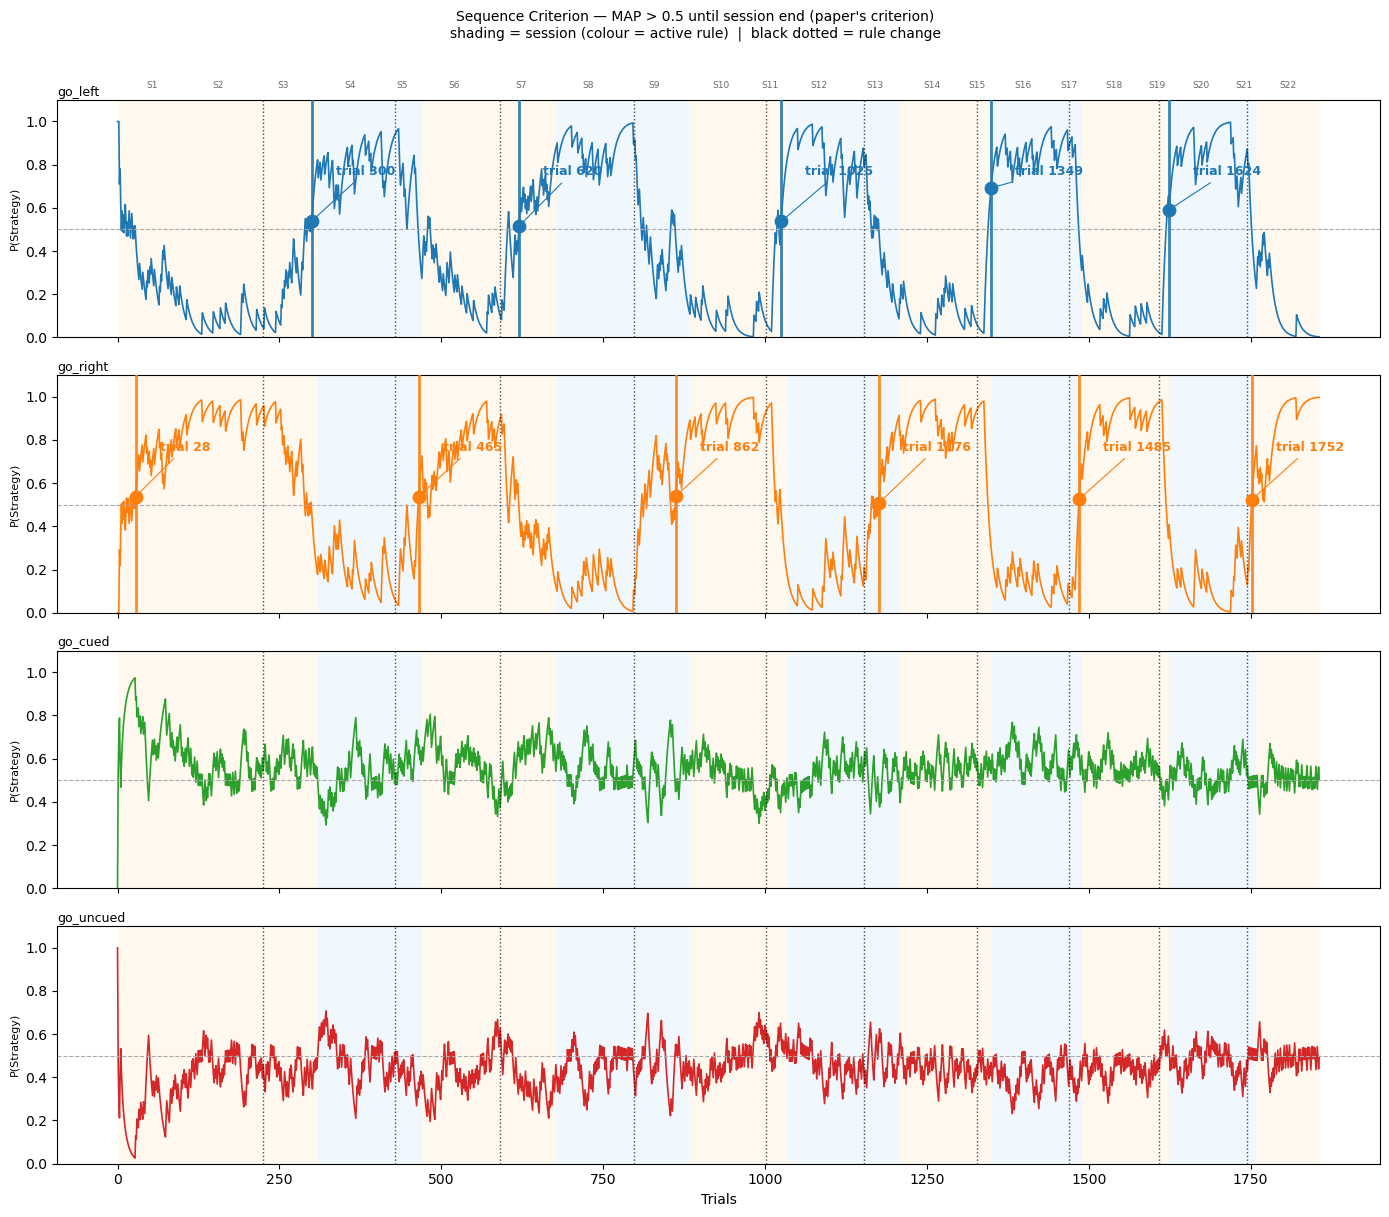


Learning trials per block:
  go right (go_right): trial 28
  go left (go_left): trial 300
  go right (go_right): trial 465
  go left (go_left): trial 620
  go right (go_right): trial 862
  go left (go_left): trial 1025
  go right (go_right): trial 1176
  go left (go_left): trial 1349
  go right (go_right): trial 1485
  go left (go_left): trial 1624
  go right (go_right): trial 1752


In [40]:
color_map = {
    "go_left":   "#1f77b4",
    "go_right":  "#ff7f0e",
    "go_cued":   "#2ca02c",
    "go_uncued": "#d62728",
}

# Background color per rule
rule_bg = {
    "go right":           "#fff3e0",  # light orange
    "go left":            "#e3f2fd",  # light blue
    "go to the lit arm":  "#e8f5e9",  # light green
    "go to the dark arm": "#fce4ec",  # light pink
}

# Build session spans: (start_idx, end_idx, session_id, rule)
session_spans = []
for sid in sorted(TestData["SessionIndex"].unique()):
    s = TestData[TestData["SessionIndex"] == sid]
    session_spans.append((s.index[0], s.index[-1], int(sid), s["TargetRule"].iloc[0]))

plot_strategies = [s for s in strategies if not s.startswith("win_stay") and not s.startswith("lose_shift")]

n = len(plot_strategies)
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)

for i, (ax, strategy) in enumerate(zip(axes, plot_strategies)):
    MAP = Output_collection[strategy]["MAPprobability"]
    color = color_map.get(strategy, "steelblue")

    # Shaded session backgrounds + session number labels (top subplot only)
    for start_idx, end_idx, sid, rule in session_spans:
        bg = rule_bg.get(rule, "#f5f5f5")
        ax.axvspan(start_idx, end_idx + 1, facecolor=bg, alpha=0.5, zorder=0)
        if i == 0:
            mid = (start_idx + end_idx) / 2
            ax.text(mid, 1.04, f"S{sid}", fontsize=6.5, color="dimgrey",
                    ha="center", va="bottom", transform=ax.get_xaxis_transform())

    ax.plot(MAP, linewidth=1.2, color=color, zorder=2)
    ax.axhline(y=0.5, color="darkgrey", linestyle="--", linewidth=0.8, zorder=2)

    # Rule change boundaries
    for b in [s[0] for s in session_spans[1:] if s[3] != session_spans[session_spans.index(s)-1][3]
              ] if False else []:  # placeholder — use block_boundaries instead
        pass
    for b in block_boundaries:
        ax.axvline(b, color="black", linestyle=":", linewidth=1.0, alpha=0.7, zorder=3)

    # Per-block learning markers
    for lt, block_strat in zip(learning_trials_blocks, block_target_strategies):
        if block_strat == strategy and lt is not None:
            ax.axvline(lt, linewidth=2, color=color, alpha=0.9, zorder=4)
            ax.scatter(lt, MAP.values[lt], s=80, color=color, zorder=5)
            ax.annotate(
                f"trial {lt}",
                xy=(lt, MAP.values[lt]),
                xytext=(lt + no_Trials * 0.02, 0.75),
                fontsize=9, color=color, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=color, lw=0.8)
            )

    ax.set_ylabel("P(Strategy)", fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(strategy, fontsize=9, loc="left", pad=3)

axes[-1].set_xlabel("Trials")
fig.suptitle("Sequence Criterion — MAP > 0.5 until session end (paper's criterion)\n"
             "shading = session (colour = active rule)  |  black dotted = rule change",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

print("\nLearning trials per block:")
for label, strat, lt in zip(block_labels, block_target_strategies, learning_trials_blocks):
    result = f"trial {lt}" if lt is not None else "not detected"
    print(f"  {label} ({strat}): {result}")

In [41]:
print(TestData[TestData["SessionIndex"] == 4][["TrialIndex", "TargetRule", "Overtrain"]].head(25))


     TrialIndex TargetRule Overtrain
310         316    go left       yes
311         317    go left       yes
312         318    go left       yes
313         319    go left       yes
314         320    go left       yes
315         321    go left       yes
316         322    go left       yes
317         323    go left       yes
318         324    go left       yes
319         325    go left       yes
320         326    go left       yes
321         327    go left       yes
322         328    go left       yes
323         329    go left       yes
324         330    go left       yes
325         331    go left       yes
326         332    go left       yes
327         333    go left       yes
328         334    go left       yes
329         335    go left       yes
330         336    go left       yes
331         337    go left       yes
332         338    go left       yes
333         339    go left       yes
334         340    go left       yes


# NEXT STEP
To compare all three learning criteria, run 4_Learning_Criteria_Comparison.ipynb